# Disciplina: Aprendizado Não Supervisionado de Máquina
## Discente: Bruno Victor Paiva da Silva - 20261006269

**1)** Seja a v.a. $X$ definida como a soma de $n$ v.a. ($X = X_1, X_2, \dots, X_n$) uniformemente distribuídas entre 0 e 1. Desenvolva um programa para obtenha a média ($E[X]$), a variância ($\sigma^2[X]$), o segundo momento ($E[X^2]$). Gere os gráficos das funções densidade de probabilidade ($f_X(X)$) e distribuição de probabilidade ($F_X(X)$), para o caso de $n = 1, 2, \dots, 12$. Analise os resultados. Para qual distribuição a v.a. $X$ tende quando o valor de $n$ aumenta? Por que isto ocorre? Há uma expressão para a média e a variância em função de $n$?

- Sugestões: use tamanho de 10.000 amostras para gerar cada sequência de v.a.. Investigue o teorema do limite central.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

n   | E[X] teo/emp           | Var[X] teo/emp         | E[X²] teo/emp
1   | 0.5000 / 0.5004      | 0.0833 / 0.0830      | 0.3333 / 0.3335
2   | 1.0000 / 0.9990      | 0.1667 / 0.1675      | 1.1667 / 1.1655
3   | 1.5000 / 1.5053      | 0.2500 / 0.2414      | 2.5000 / 2.5074
4   | 2.0000 / 2.0049      | 0.3333 / 0.3325      | 4.3333 / 4.3520
5   | 2.5000 / 2.4904      | 0.4167 / 0.4190      | 6.6667 / 6.6209
6   | 3.0000 / 3.0075      | 0.5000 / 0.5033      | 9.5000 / 9.5481
7   | 3.5000 / 3.4970      | 0.5833 / 0.5815      | 12.8333 / 12.8107
8   | 4.0000 / 4.0008      | 0.6667 / 0.6746      | 16.6667 / 16.6813
9   | 4.5000 / 4.4933      | 0.7500 / 0.7449      | 21.0000 / 20.9348
10  | 5.0000 / 5.0017      | 0.8333 / 0.8390      | 25.8333 / 25.8560
11  | 5.5000 / 5.4955      | 0.9167 / 0.9310      | 31.1667 / 31.1314
12  | 6.0000 / 6.0022      | 1.0000 / 0.9702      | 37.0000 / 36.9966


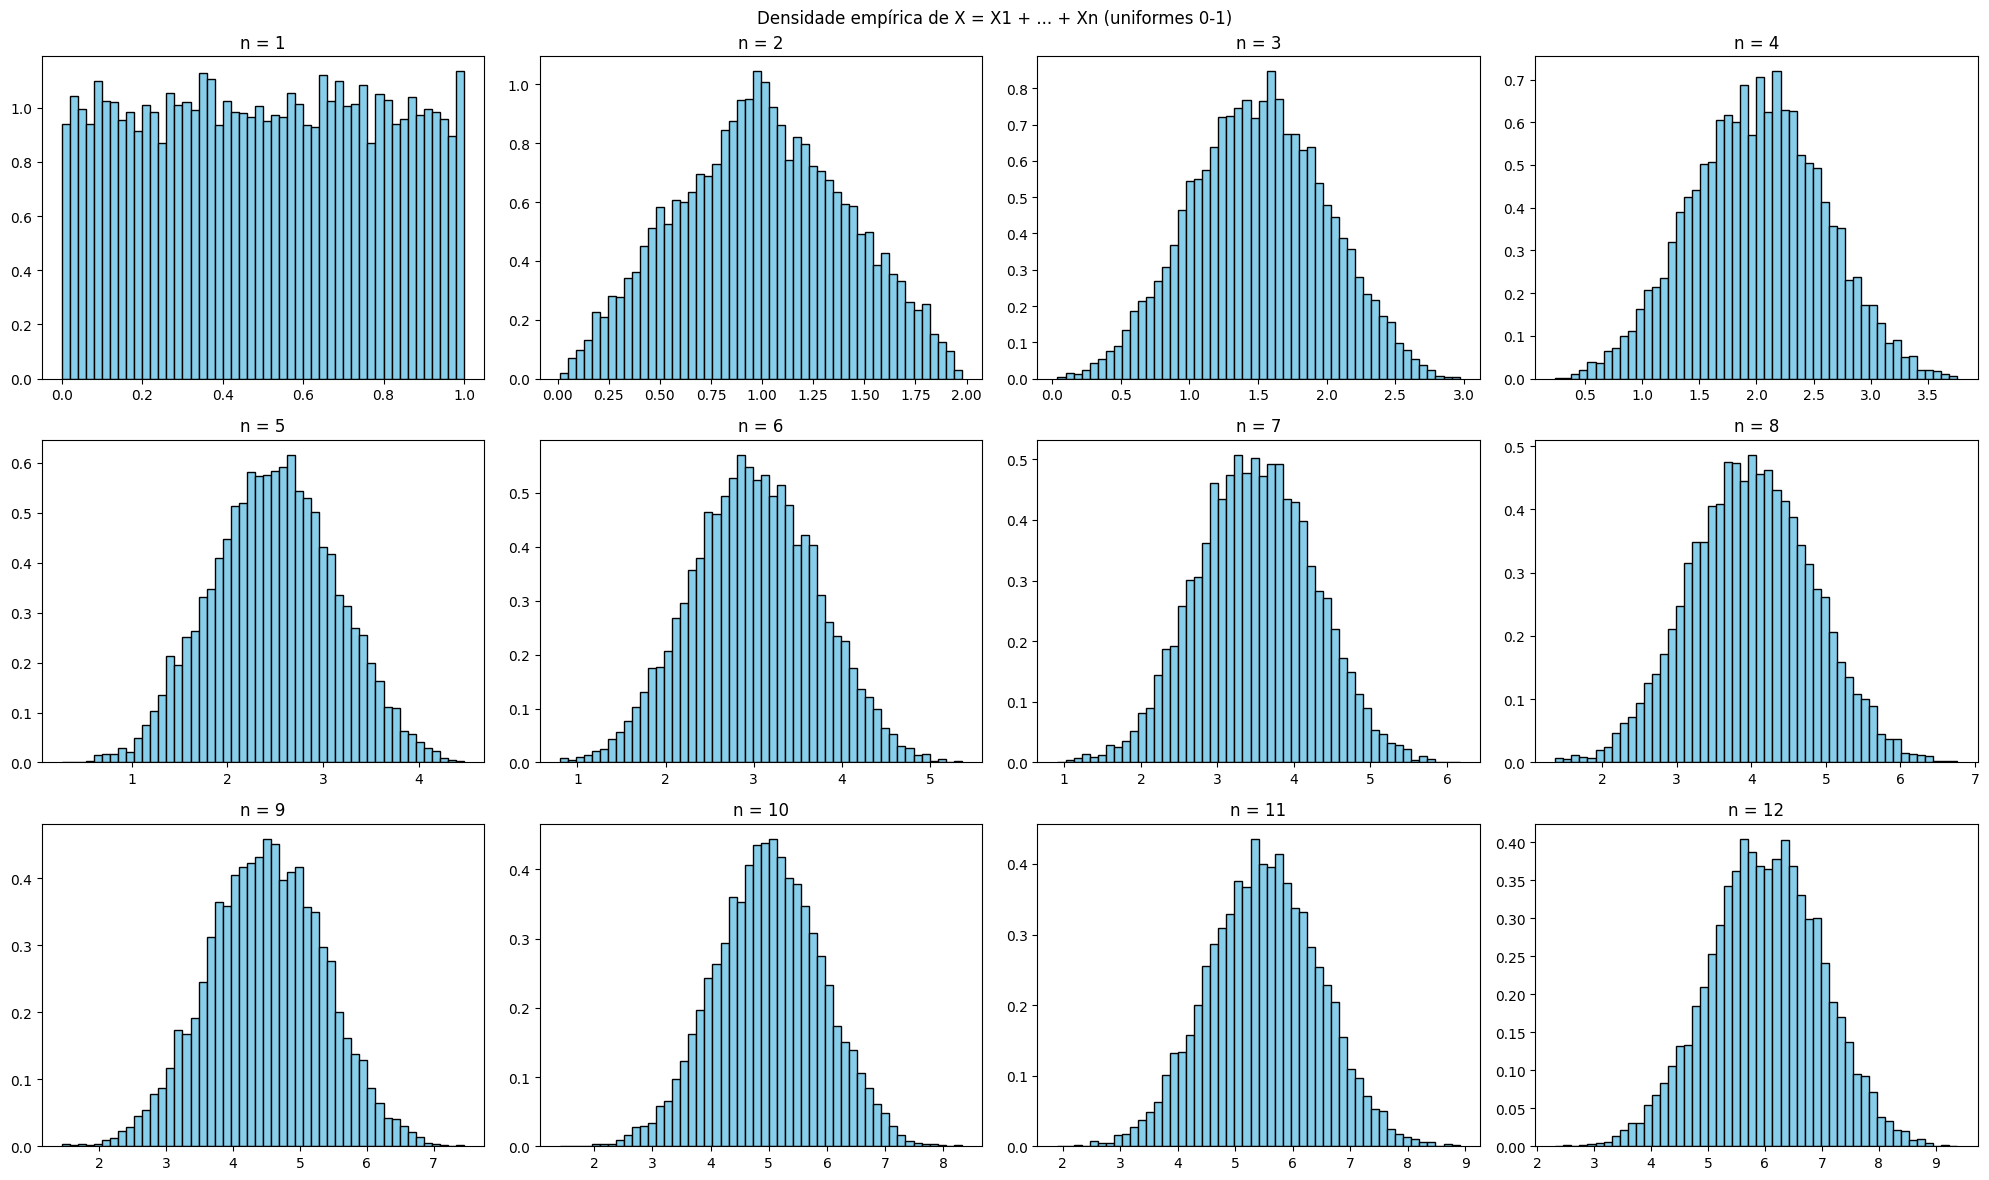

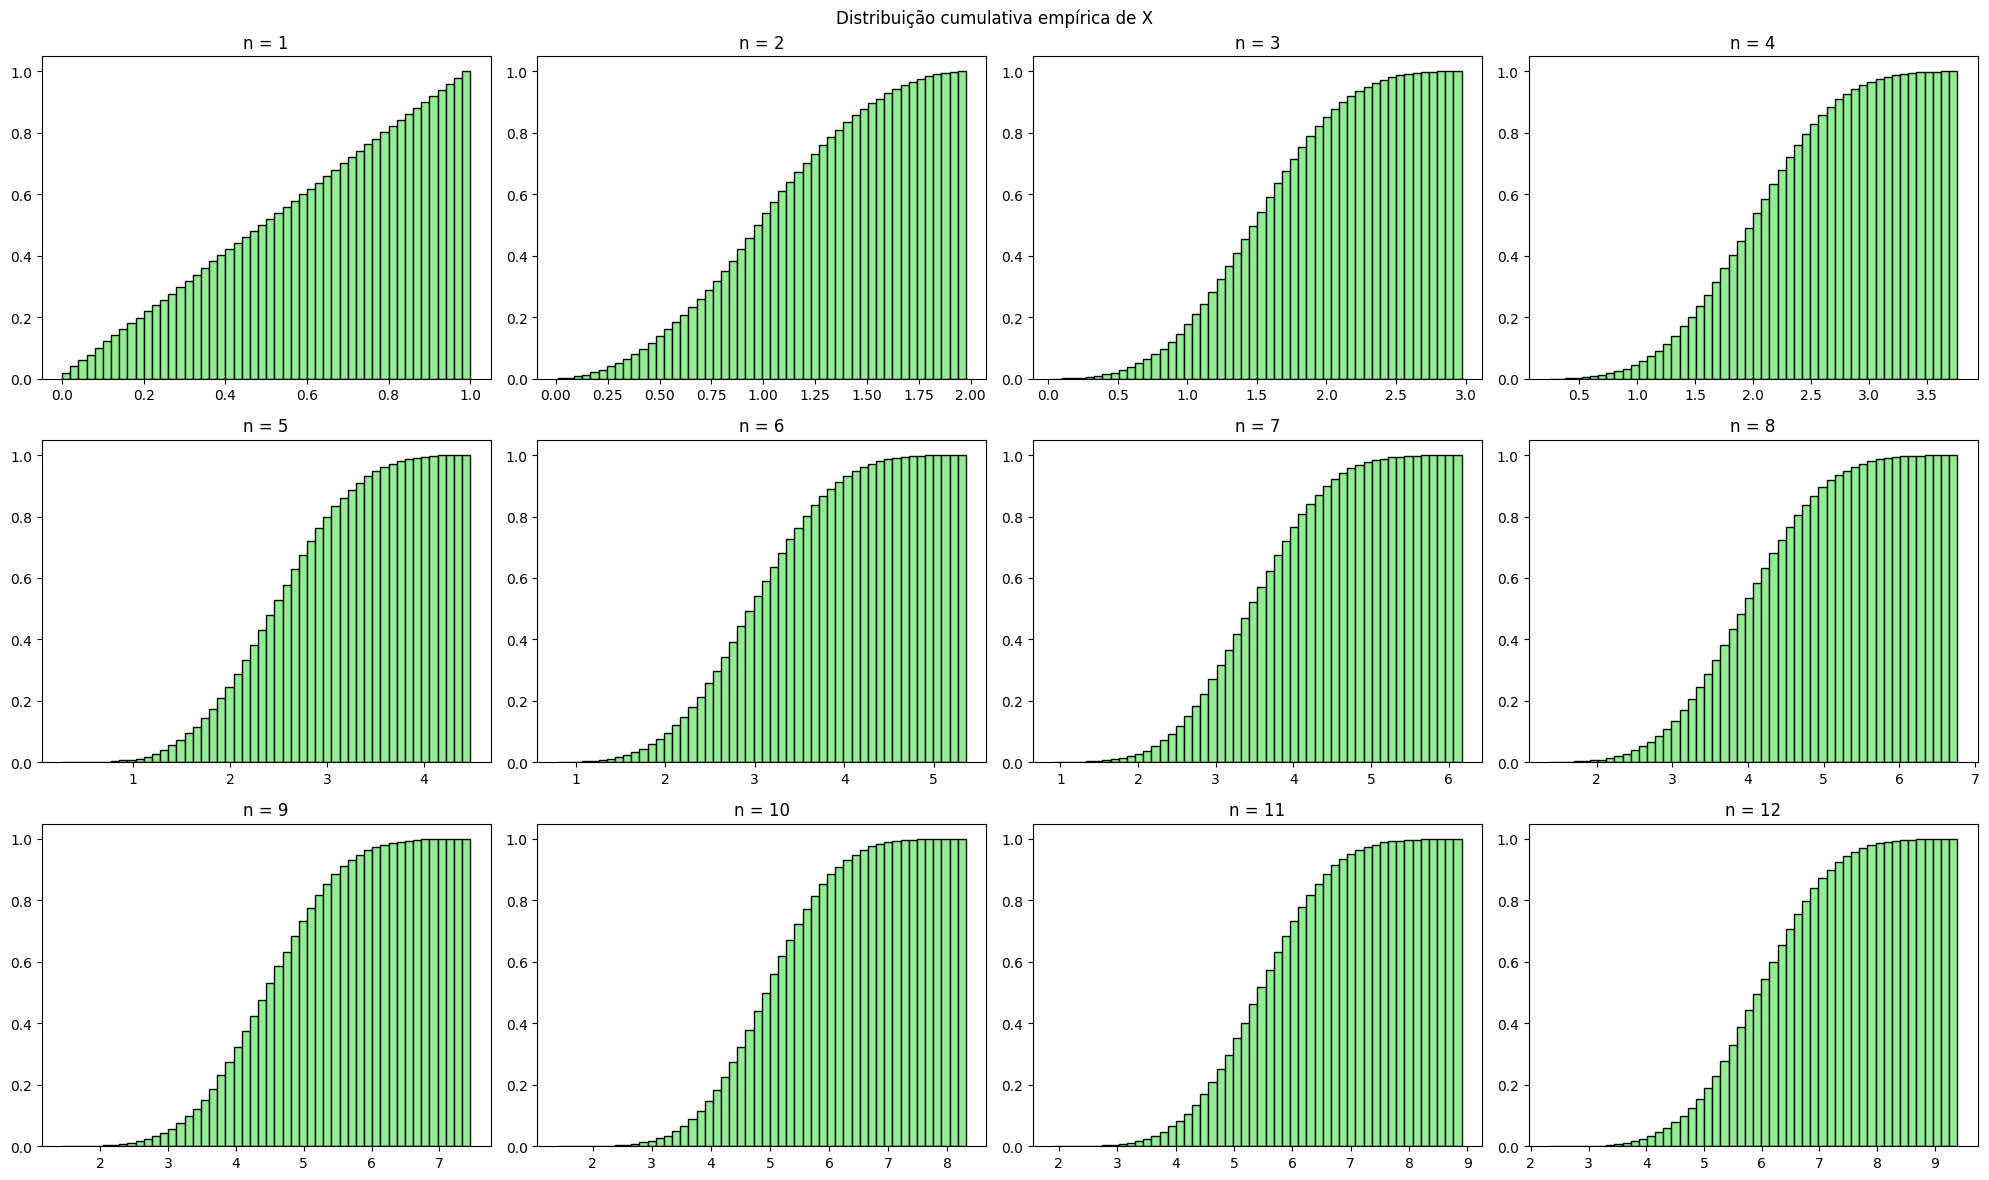

In [36]:
n_max = 12
amostras = 10000

fig_pdf, axs_pdf = plt.subplots(3, 4, figsize=(20, 12))
fig_cdf, axs_cdf = plt.subplots(3, 4, figsize=(20, 12))

print(f"{'n':<3} | {'E[X] teo/emp':<22} | {'Var[X] teo/emp':<22} | {'E[X²] teo/emp'}")

for i in range(1, n_max + 1):
    v_aleatorias = stats.uniform.rvs(loc=0, scale=1, size=(amostras, i))
    X = np.sum(v_aleatorias, axis=1)

    media_emp = np.mean(X)
    var_emp = np.var(X)
    momento2_emp = np.mean(X**2)

    media_teo = i / 2
    var_teo = i / 12
    momento2_teo = var_teo + media_teo**2

    print(f"{i:<3} | {media_teo:.4f} / {media_emp:.4f}      | {var_teo:.4f} / {var_emp:.4f}      | {momento2_teo:.4f} / {momento2_emp:.4f}")

    row, col = (i - 1) // 4, (i - 1) % 4

    axs_pdf[row, col].hist(X, bins=50, density=True, color='skyblue', edgecolor='black')
    axs_pdf[row, col].set_title(f'n = {i}')

    axs_cdf[row, col].hist(X, bins=50, density=True, cumulative=True, color='lightgreen', edgecolor='black')
    axs_cdf[row, col].set_title(f'n = {i}')

fig_pdf.suptitle('Densidade empírica de X = X1 + ... + Xn (uniformes 0-1)')
fig_cdf.suptitle('Distribuição cumulativa empírica de X')
fig_pdf.tight_layout()
fig_cdf.tight_layout()
plt.show()